<a href="https://colab.research.google.com/github/moise97/Extract_-_Structure_Data_from_SDFs_pharmaceutical_documentation/blob/main/Analyze_a_Scanned_PDF_pharmaceutical_document_(pt_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

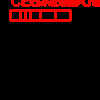

In [11]:
import cv2
from PIL import Image
import numpy as np

# Define key fields to highlight
key_fields = ["CERTIFICATE", "CERTIFICATE OF ANALYSIS", "LOT", "BATCH", "VENDOR", "EXPIRATION", "DATE", "SIGNATURE", "COA", "MANUFACTURER" ]

# --- Placeholder definitions for 'gray' and 'ocr_data' (REPLACE THESE WITH YOUR ACTUAL DATA) ---
# 'gray' should be a preprocessed grayscale image (e.g., from cv2.imread or a previous processing step).
# Example dummy grayscale image (100x100 black image):
gray = np.zeros((100, 100), dtype=np.uint8)

# 'ocr_data' should contain the results from an OCR process (e.g., pytesseract.image_to_data output).
# Example dummy ocr_data:
ocr_data = {
    'level': [1, 2, 3, 4, 5],
    'page_num': [1, 1, 1, 1, 1],
    'block_num': [1, 1, 1, 1, 1],
    'par_num': [1, 1, 1, 1, 1],
    'line_num': [1, 1, 1, 1, 1],
    'word_num': [1, 1, 1, 1, 1],
    'left': [10, 20, 30, 40, 50], # x-coordinate of the word bounding box
    'top': [10, 10, 10, 10, 10],  # y-coordinate of the word bounding box
    'width': [15, 20, 25, 30, 35], # width of the word bounding box
    'height': [10, 10, 10, 10, 10],# height of the word bounding box
    'conf': [90, 90, 90, 90, 90],  # confidence score
    'text': ['CERTIFICATE', 'LOT', 'BATCH', 'VENDOR', 'NOTAKEYWORD'] # recognized text
}
# ------------------------------------------------------------------------------------------------

# Convert preprocessed grayscale image to BGR format (so we can draw colored boxes)
# Note: We use 'gray' because that's the image OCR was run on, so coordinates will match
img_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

# Loop through extracted OCR words
for i in range(len(ocr_data["text"])):
    word = ocr_data["text"][i].strip().upper() # Convert to uppercase for better matching
    # Ensure the index 'i' is within the bounds of all lists in ocr_data dictionary
    if i < len(ocr_data["left"]):
        x, y, w, h = ocr_data["left"][i], ocr_data["top"][i], ocr_data["width"][i], ocr_data["height"][i]

        if word in key_fields: # Highlight only key fields found in the document
            cv2.rectangle(img_bgr, (x, y), (x + w, y + h), (0, 0, 255), 2) # Red bounding box
            cv2.putText(img_bgr, word, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

# Convert back to RGB for display
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
display(Image.fromarray(img_rgb))

## Install Necessary Libraries

We'll need `PyMuPDF` (for PDF handling), `pytesseract` (the Python wrapper for Tesseract OCR), and `opencv-python` (for image pre-processing). We also need to install the Tesseract OCR engine itself, as `pytesseract` is just a wrapper.



In [12]:
# Install PyMuPDF for PDF processing
!pip install PyMuPDF pytesseract opencv-python --quiet

# Install tesseract-ocr
!sudo apt update --quiet
!sudo apt install tesseract-ocr --quiet

import fitz # PyMuPDF
import pytesseract
import cv2
import numpy as np
from PIL import Image
import re
import json
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 77.2 MB/s eta 0:00:00
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,915 kB]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [93.4 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,294 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,004 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRel

## 1. Load the Document and Initial Grayscale Conversion

This step involves opening the PDF document and converting a specific page into an image. For OCR, it's generally best to work with grayscale images, as color information is usually not relevant for text recognition and can sometimes introduce noise. We will convert the image to a NumPy array for further processing with OpenCV.


Document loaded and converted to grayscale image with shape: (2376, 1836)


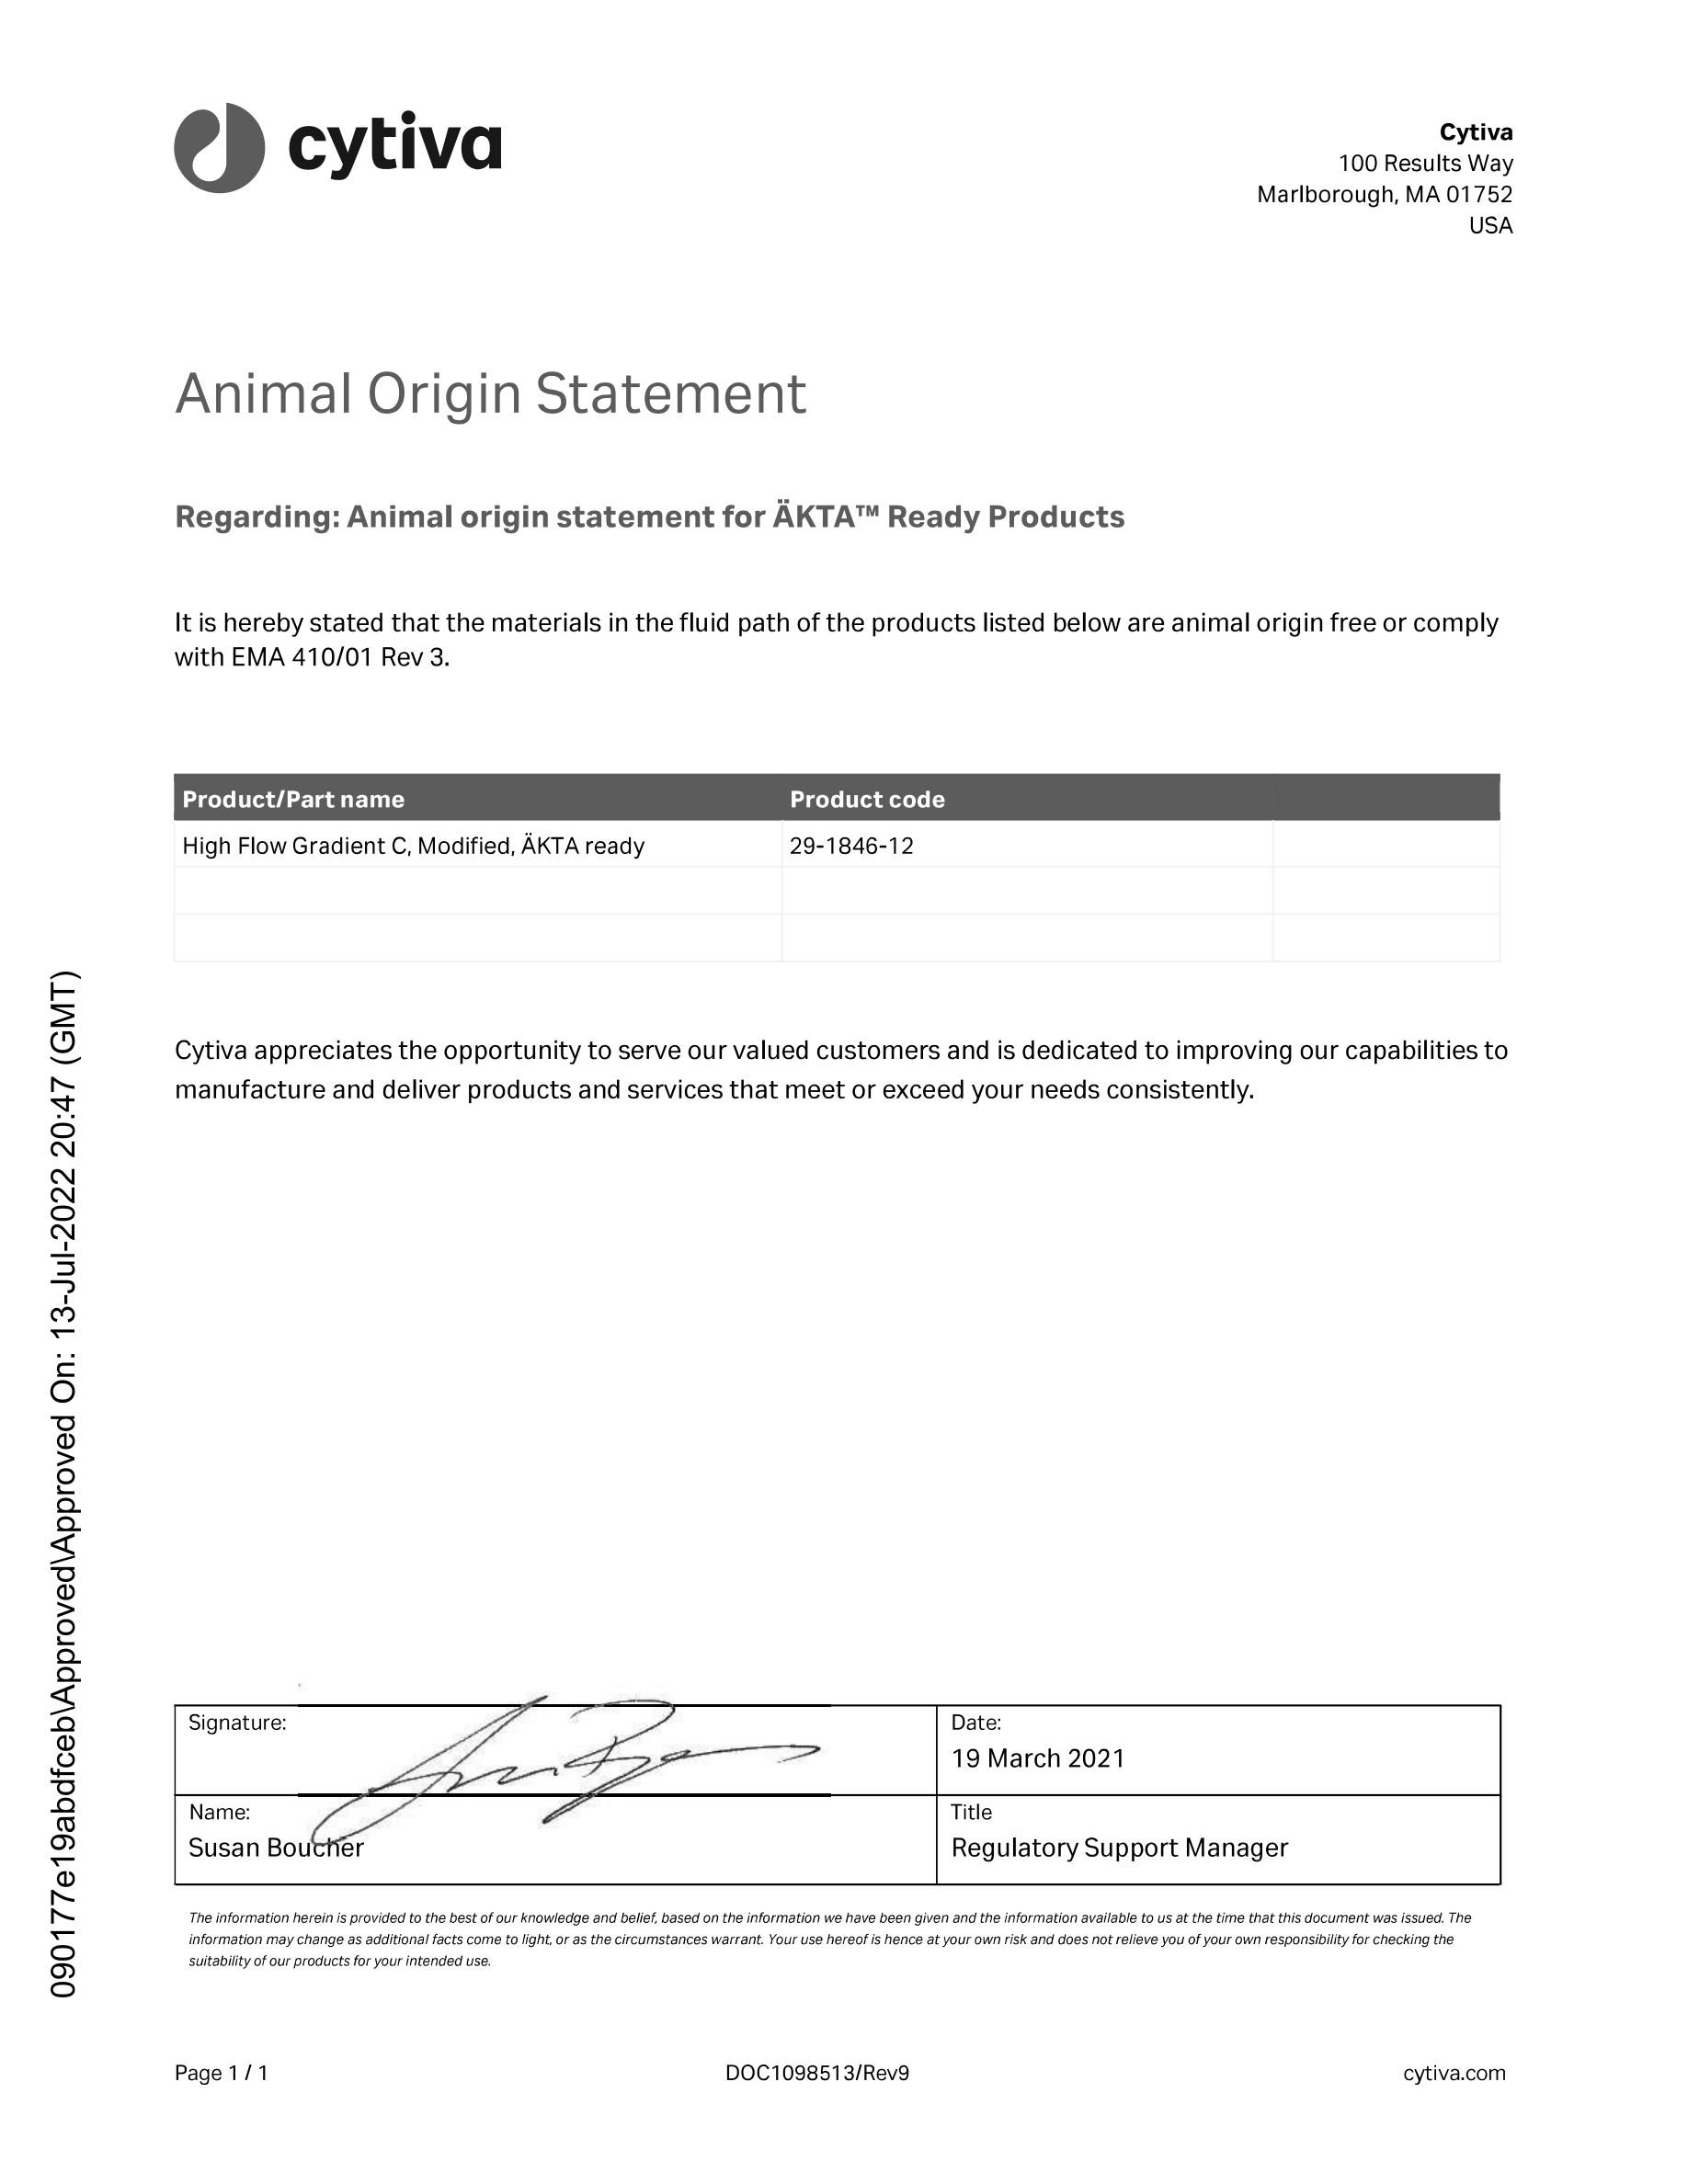

In [13]:
# Load the PDF document
document_path = '/content/pharmaceutical-sdf-page2-animal-origin extern_week 4 project.pdf'

try:
    doc = fitz.open(document_path)
    page = doc[0] # Get the first page

    # Render page to an image ( высокого качества)
    pix = page.get_pixmap(matrix=fitz.Matrix(3, 3)) # 3x zoom for higher resolution

    # Convert to a NumPy array for OpenCV processing
    img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.h, pix.w, pix.n)

    # Convert RGB or RGBA to grayscale if not already
    if img.shape[2] == 3: # RGB
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    elif img.shape[2] == 4: # RGBA
        gray = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)
    else:
        gray = img # Already grayscale

    print(f"Document loaded and converted to grayscale image with shape: {gray.shape}")
    display(Image.fromarray(gray)) # Display the grayscale image

except Exception as e:
    print(f"Error loading or processing document: {e}")
    # Set dummy gray image and ocr_data for subsequent cells to run without error
    gray = np.zeros((100, 100), dtype=np.uint8)
    ocr_data = {
        'level': [], 'page_num': [], 'block_num': [], 'par_num': [], 'line_num': [],
        'word_num': [], 'left': [], 'top': [], 'width': [], 'height': [], 'conf': [], 'text': []
    }

## 2. Image Pre-processing for OCR Accuracy

Image pre-processing is crucial for improving the accuracy of OCR. We'll apply several techniques:

*   **Deskewing**: Corrects any slight rotation in the image, ensuring text lines are perfectly horizontal.
*   **Noise Reduction (Denoising)**: Removes unwanted speckles and distortions from the image that can confuse the OCR engine. A median filter is effective for salt-and-pepper noise.
*   **Thresholding**: Converts the grayscale image into a binary (black and white) image, making text stand out more clearly against the background. Adaptive thresholding is often preferred as it adjusts to varying lighting conditions across the image.

Each step aims to make the text characters clearer and more distinct for Tesseract.


Image pre-processing completed (deskewing, denoising, thresholding).


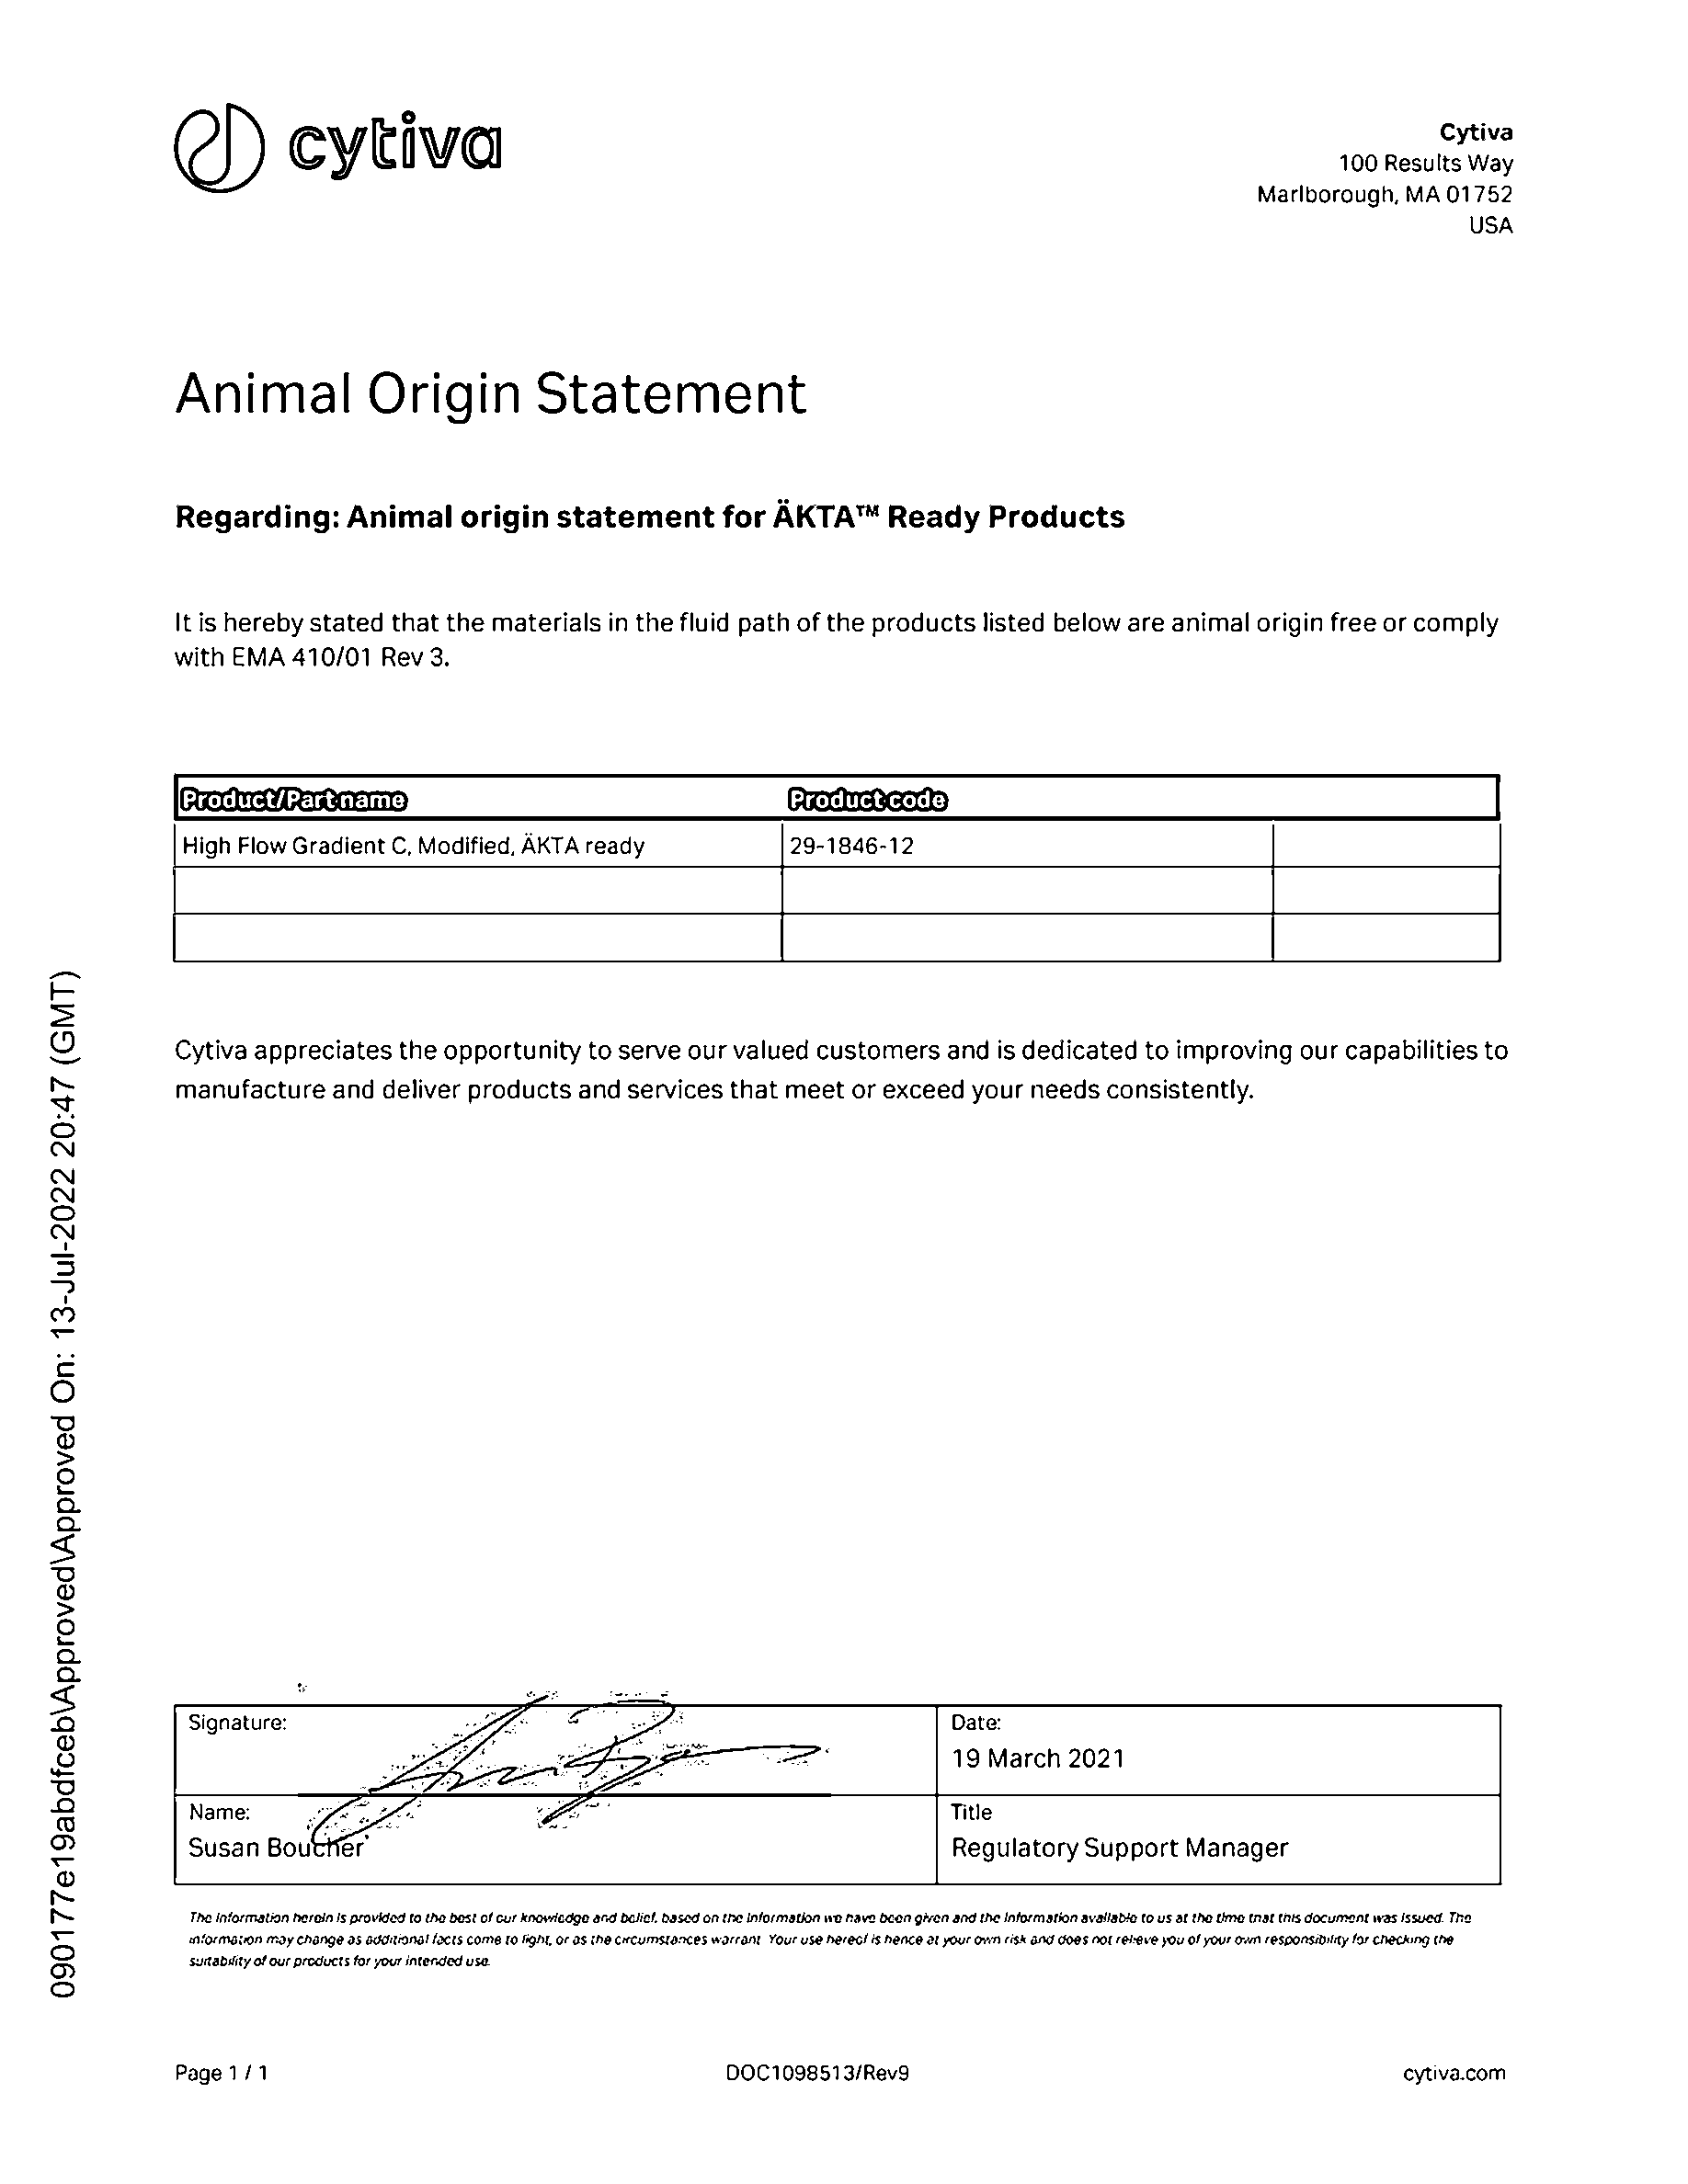

In [14]:
# Function to deskew the image
def deskew(image):
    coords = np.column_stack(np.where(image > 0))
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    return rotated

# Apply deskewing
deskewed_image = deskew(gray)

# Apply noise reduction (Median Blurring is effective for salt-and-pepper noise)
denoised_image = cv2.medianBlur(deskewed_image, 3) # Kernel size 3x3

# Apply adaptive thresholding
# cv2.ADAPTIVE_THRESH_GAUSSIAN_C uses a Gaussian weighted sum of neighbourhood values
# cv2.THRESH_BINARY applies a binary threshold
# Block size 11, C value 2
thresholded_image = cv2.adaptiveThreshold(
denoised_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

preprocessed_image = thresholded_image # Final preprocessed image

print("Image pre-processing completed (deskewing, denoising, thresholding).")
display(Image.fromarray(preprocessed_image)) # Display the preprocessed image

## 3. Apply Tesseract OCR to Extract Text and Bounding Boxes

Now we'll use `pytesseract` to perform Optical Character Recognition on the pre-processed image. `image_to_data` is particularly useful as it not only extracts text but also provides detailed information about each detected word, including its bounding box coordinates, confidence score, and hierarchical structure (page, block, paragraph, line, word).

This rich output is essential for localizing specific information on the document.


In [15]:
# Perform OCR using pytesseract, getting detailed box and text data
ocr_data = pytesseract.image_to_data(preprocessed_image, output_type=pytesseract.Output.DICT)

# Display the raw OCR data structure for inspection
# print("Raw OCR Data:")
# for key, value in ocr_data.items():
#     print(f"{key}: {value[:10]}...") # Print first 10 elements for brevity

print(f"OCR extracted {len(ocr_data['text'])} potential words.")

OCR extracted 276 potential words.


## 4. Clean the OCR Output

OCR is not always perfect, and raw output can contain errors, misreads, and formatting issues. This step focuses on cleaning the extracted text to improve its quality for further analysis. Common cleaning tasks include:

*   **Filtering out low-confidence reads**: Words with very low confidence scores are likely misreads and can be ignored.
*   **Removing empty strings or non-alphanumeric noise**: Tesseract might detect noise as 'text', which needs to be filtered out.
*   **Correcting common OCR errors**: Using regular expressions or mapping common misreads (e.g., '1' for 'l', '0' for 'O').

For this example, we'll focus on filtering low-confidence words and empty strings.

In [16]:
cleaned_ocr_data = {
    'text': [], 'left': [], 'top': [], 'width': [], 'height': [], 'conf': []
}

min_conf = 60 # Minimum confidence score to consider a word valid

for i in range(len(ocr_data['text'])):
    word = ocr_data['text'][i].strip()
    conf = int(ocr_data['conf'][i])

    # Filter out empty words, words with very low confidence, or single non-alphanumeric characters
    if word and conf > min_conf and len(word) > 1 or (len(word) == 1 and word.isalnum()):
        cleaned_ocr_data['text'].append(word)
        cleaned_ocr_data['left'].append(ocr_data['left'][i])
        cleaned_ocr_data['top'].append(ocr_data['top'][i])
        cleaned_ocr_data['width'].append(ocr_data['width'][i])
        cleaned_ocr_data['height'].append(ocr_data['height'][i])
        cleaned_ocr_data['conf'].append(conf)

print(f"Cleaned OCR data contains {len(cleaned_ocr_data['text'])} words after filtering low confidence and empty strings.")

Cleaned OCR data contains 160 words after filtering low confidence and empty strings.


## 5. Identify and Localize Key Information using Bounding Boxes

This is the core extraction step. We'll iterate through the cleaned OCR output to find specific keywords or patterns corresponding to the required information (vendor, product, document type, dates, etc.). Once a key piece of information is found, we'll store its text and its bounding box coordinates.

We will define patterns and keywords for each requested field:
*   **Vendor name**: "Cytiva"
*   **Product name and code**: Often found near product identifiers.
*   **Document type**: "Animal Origin Statement"
*   **Signature date**: Look for date formats.
*   **Signatory name and title**: Usually appear together near a signature.
*   **Document reference number**: Look for patterns like "REF", "DOC NO", followed by alphanumeric codes.

Since the OCR data gives us word-level bounding boxes, we can precisely locate these items.

Key information extraction and localization complete.


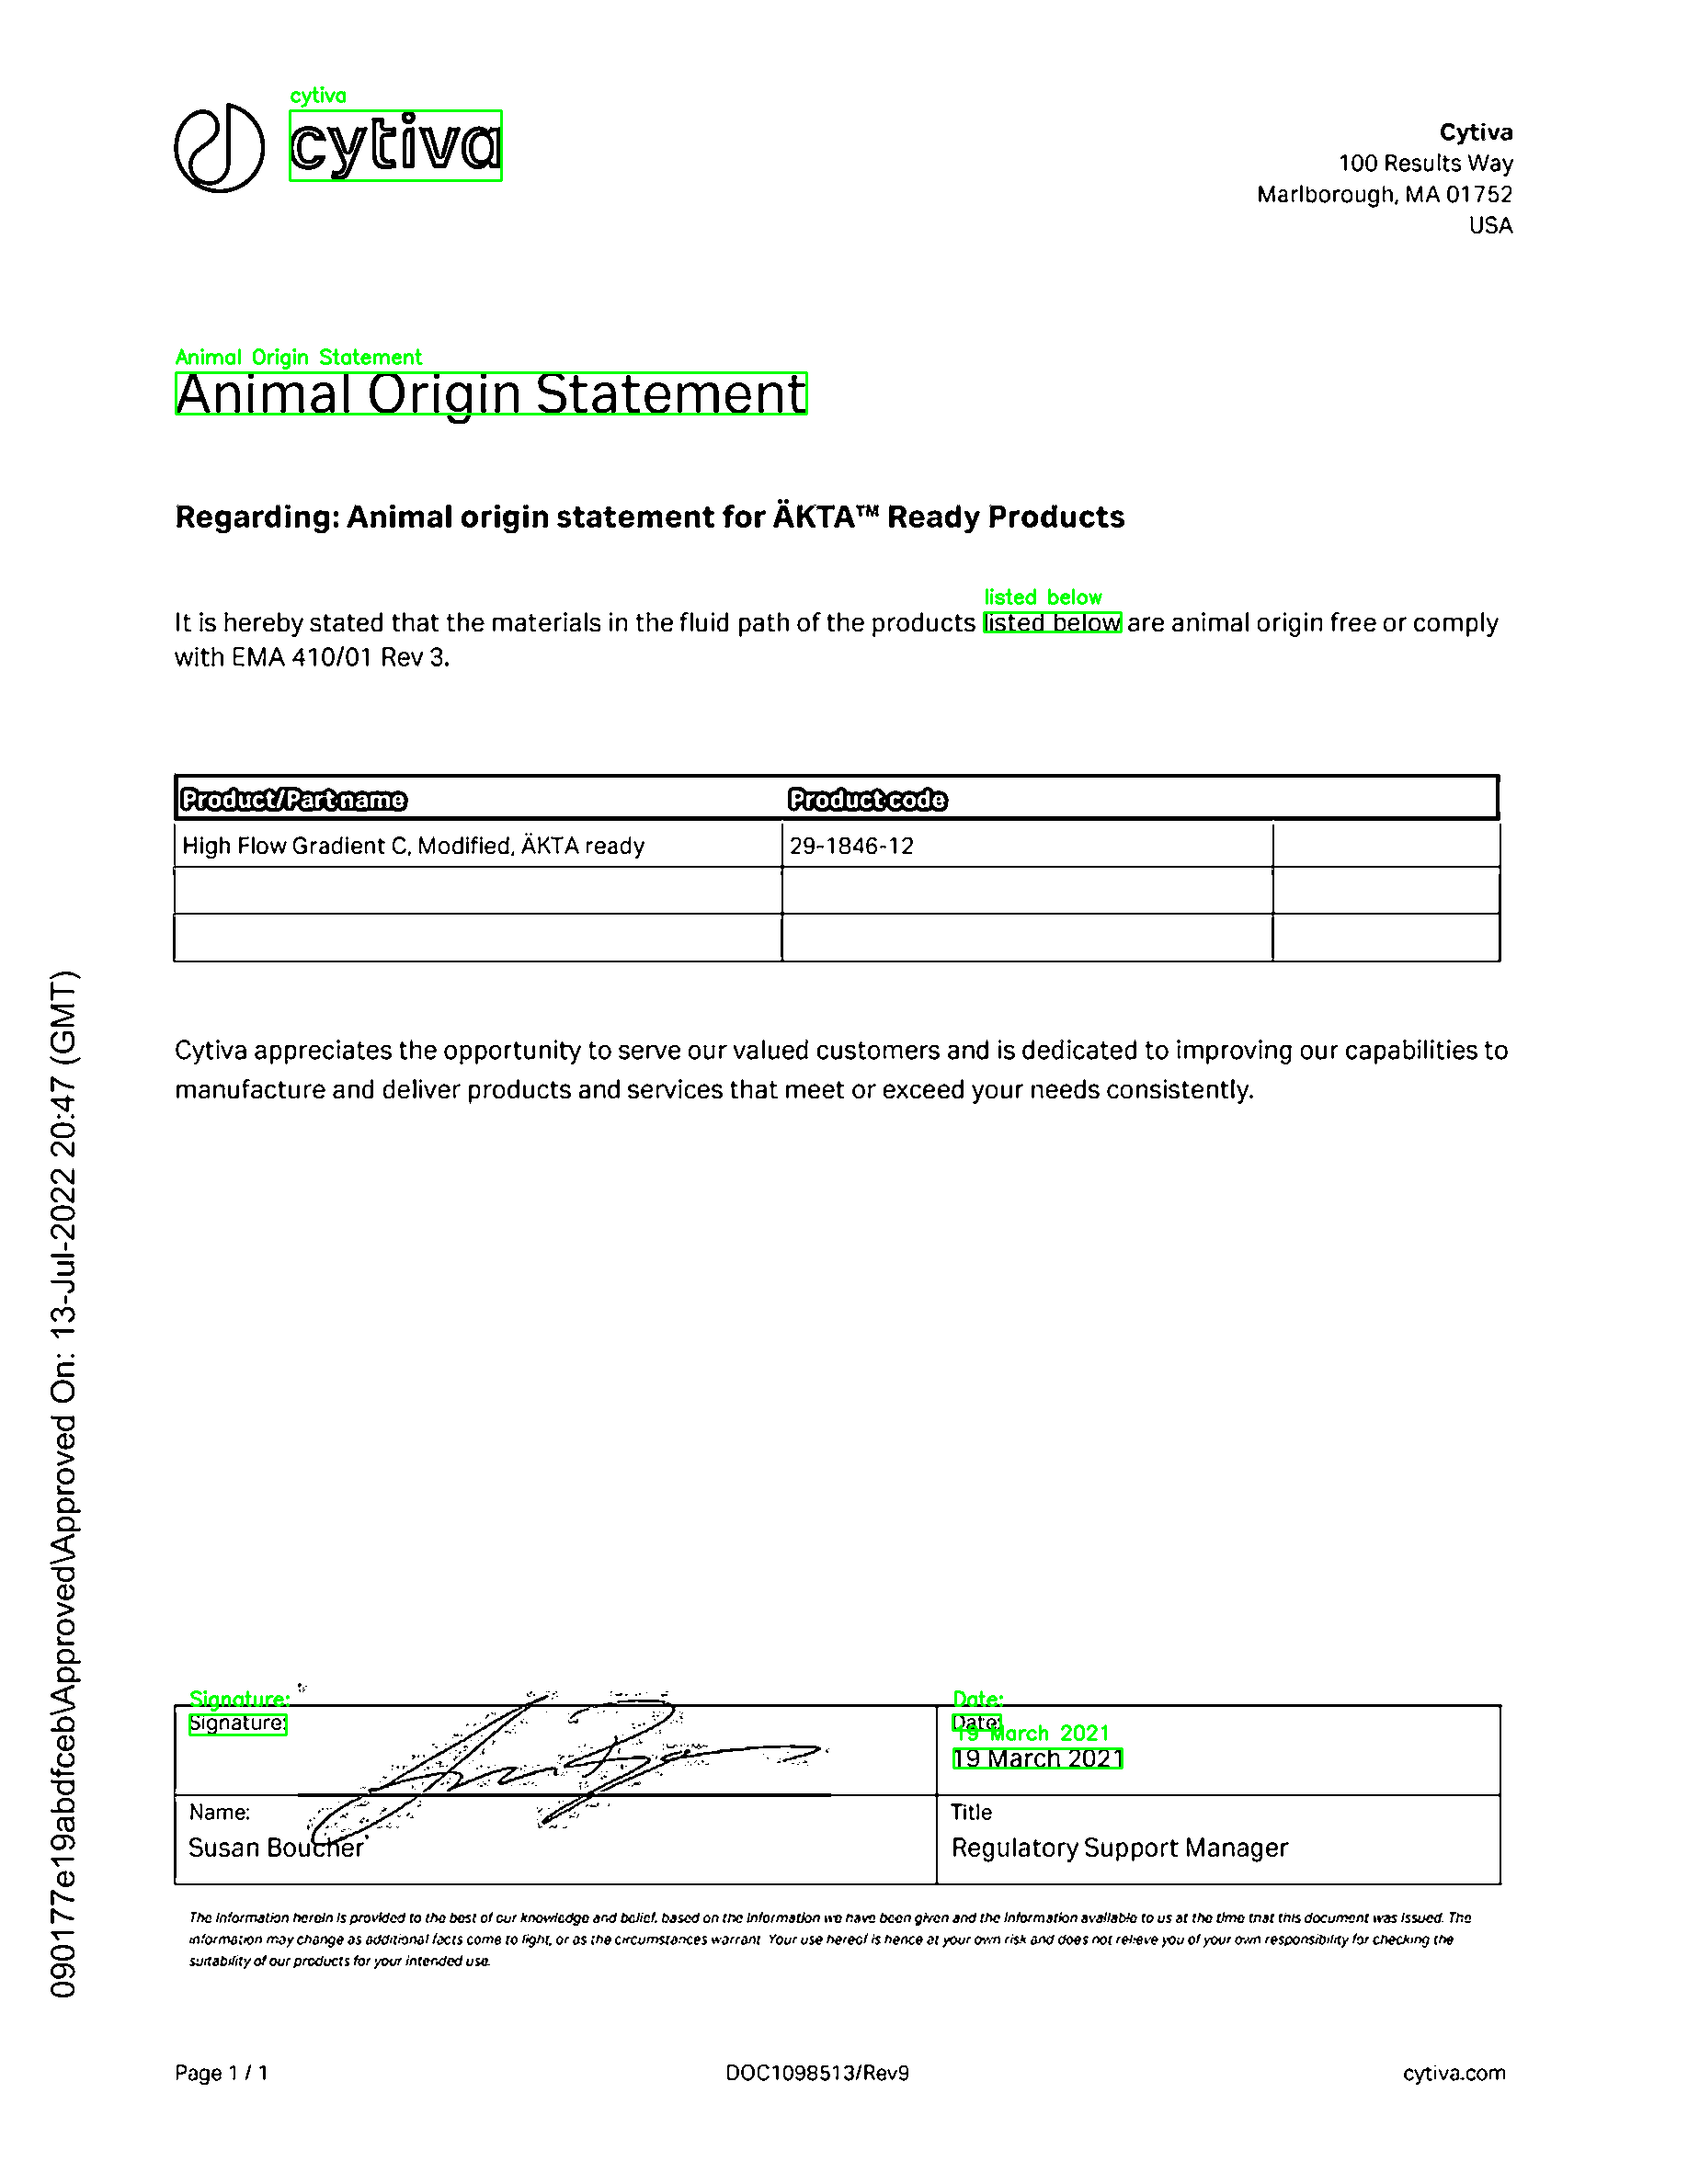

In [17]:
extracted_info = {}

# Convert preprocessed grayscale image to BGR for drawing
img_display = cv2.cvtColor(preprocessed_image, cv2.COLOR_GRAY2BGR)

# Helper function to find text near another text (for value extraction)
def find_text_near(target_word_index, search_direction='right', max_distance_x=150, max_distance_y=20, num_words=1):
    target_left = cleaned_ocr_data['left'][target_word_index]
    target_top = cleaned_ocr_data['top'][target_word_index]
    target_height = cleaned_ocr_data['height'][target_word_index]
    target_text = cleaned_ocr_data['text'][target_word_index]

    found_words = []
    for i in range(len(cleaned_ocr_data['text'])):
        if i == target_word_index: continue

        current_left = cleaned_ocr_data['left'][i]
        current_top = cleaned_ocr_data['top'][i]
        current_width = cleaned_ocr_data['width'][i]
        current_height = cleaned_ocr_data['height'][i]
        current_text = cleaned_ocr_data['text'][i]

        # Check if words are on roughly the same line (vertical alignment)
        if abs(current_top - target_top) < max_distance_y:
            if search_direction == 'right' and current_left > (target_left + cleaned_ocr_data['width'][target_word_index]) and \
               (current_left - (target_left + cleaned_ocr_data['width'][target_word_index])) < max_distance_x:
                found_words.append((current_text, current_left, current_top, current_width, current_height))
            elif search_direction == 'below' and current_top > (target_top + target_height):
                 found_words.append((current_text, current_left, current_top, current_width, current_height))

    # Sort found words by their x-coordinate to get them in order
    if search_direction == 'right':
        found_words.sort(key=lambda x: x[1])
    elif search_direction == 'below':
        found_words.sort(key=lambda x: x[2]) # Sort by top for below

    if found_words:
        # Combine text and adjust bounding box to encompass all found words
        combined_text = ' '.join([fw[0] for fw in found_words[:num_words]])
        min_x = min([fw[1] for fw in found_words[:num_words]])
        min_y = min([fw[2] for fw in found_words[:num_words]])
        max_x = max([fw[1] + fw[3] for fw in found_words[:num_words]])
        max_y = max([fw[2] + fw[4] for fw in found_words[:num_words]])
        return {"text": combined_text, "bbox": [min_x, min_y, max_x, max_y]}
    return None


# Keywords and patterns for extraction
vendor_keywords = ["VENDOR", "SUPPLIER", "MANUFACTURER"] # Cytiva
product_keywords = ["PRODUCT", "ITEM", "CODE"]
document_type_keywords = ["STATEMENT", "CERTIFICATE", "REPORT", "DECLARATION"]
signature_date_patterns = [r'\d{1,2}[-/]\d{1,2}[-/]\d{2,4}', r'\d{4}-\d{2}-\d{2}', r'(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s\d{1,2},\s\d{4}']
signatory_keywords = ["SIGNATURE", "SIGNED BY", "FOR", "BY"]
document_ref_keywords = ["REFERENCE", "DOC NO", "DOCUMENT NO", "REF"]
lot_batch_keywords = ["LOT", "BATCH"]
expiration_keywords = ["EXPIRATION", "EXP DATE", "EXPIRES"]

found_key_fields = [] # To store the found (key, bbox) tuples for drawing

# Iterate through cleaned OCR data to find key information
for i in range(len(cleaned_ocr_data['text'])):
    word = cleaned_ocr_data['text'][i].upper()
    x, y, w, h = cleaned_ocr_data['left'][i], cleaned_ocr_data['top'][i], cleaned_ocr_data['width'][i], cleaned_ocr_data['height'][i]

    # Generic key fields (CERTIFICATE, LOT, BATCH, VENDOR, EXPIRATION, DATE, SIGNATURE, COA, MANUFACTURER)
    for key_field in key_fields:
        if key_field == "CERTIFICATE OF ANALYSIS":
            if "CERTIFICATE" in word and "ANALYSIS" in cleaned_ocr_data['text'][i+1].upper():
                # If "CERTIFICATE" and "OF" and "ANALYSIS" are consecutive
                if i + 2 < len(cleaned_ocr_data['text']) and cleaned_ocr_data['text'][i+1].upper() == 'OF' and cleaned_ocr_data['text'][i+2].upper() == 'ANALYSIS':
                    # Combine bounding box for "CERTIFICATE OF ANALYSIS"
                    x1 = cleaned_ocr_data['left'][i]
                    y1 = cleaned_ocr_data['top'][i]
                    x2 = cleaned_ocr_data['left'][i+2] + cleaned_ocr_data['width'][i+2]
                    y2 = cleaned_ocr_data['top'][i+2] + cleaned_ocr_data['height'][i+2]
                    bbox = [x1, y1, x2, y2]
                    extracted_info["Document Type"] = {"text": "CERTIFICATE OF ANALYSIS", "bbox": bbox}
                    found_key_fields.append((("CERTIFICATE OF ANALYSIS"), bbox))
                    # Skip next two words as they are part of this phrase
                    # (not ideal for 'for' loop, but demonstrating extraction)
                continue
        elif key_field in word:
            bbox = [x, y, x + w, y + h]
            # Avoid overwriting if a more specific match is found later
            if key_field not in extracted_info:
                extracted_info[key_field.replace('_', ' ').title()] = {"text": cleaned_ocr_data['text'][i], "bbox": bbox}
                found_key_fields.append((cleaned_ocr_data['text'][i], bbox))

    # Vendor Name (Cytiva) - Specific search
    if "CYTIVA" in word:
        if "Vendor Name" not in extracted_info:
            extracted_info["Vendor Name"] = {"text": cleaned_ocr_data['text'][i], "bbox": [x, y, x + w, y + h]}
            found_key_fields.append((cleaned_ocr_data['text'][i], [x, y, x + w, y + h]))

    # Document Type (Animal Origin Statement) - Specific search
    if "ANIMAL" in word and i + 2 < len(cleaned_ocr_data['text']) and \
       cleaned_ocr_data['text'][i+1].upper() == 'ORIGIN' and cleaned_ocr_data['text'][i+2].upper() == 'STATEMENT':
        if "Document Type" not in extracted_info or "ANIMAL ORIGIN STATEMENT" not in extracted_info["Document Type"]["text"].upper():
            # Combine bounding box for "Animal Origin Statement"
            x1 = cleaned_ocr_data['left'][i]
            y1 = cleaned_ocr_data['top'][i]
            x2 = cleaned_ocr_data['left'][i+2] + cleaned_ocr_data['width'][i+2]
            y2 = cleaned_ocr_data['top'][i+2] + cleaned_ocr_data['height'][i+2]
            bbox = [x1, y1, x2, y2]
            extracted_info["Document Type"] = {"text": "Animal Origin Statement", "bbox": bbox}
            found_key_fields.append((("Animal Origin Statement"), bbox))

    # Signature Date - Look for date patterns
    for pattern in signature_date_patterns:
        if re.match(pattern, word, re.IGNORECASE):
            if "Signature Date" not in extracted_info:
                extracted_info["Signature Date"] = {"text": cleaned_ocr_data['text'][i], "bbox": [x, y, x + w, y + h]}
                found_key_fields.append((cleaned_ocr_data['text'][i], [x, y, x + w, y + h]))
            break # Found a date, move to next word

    # Document Reference Number - Look for keywords + value to the right
    if any(keyword in word for keyword in document_ref_keywords) and "Document Reference Number" not in extracted_info:
        ref_value = find_text_near(i, search_direction='right', num_words=2)
        if ref_value:
            extracted_info["Document Reference Number"] = ref_value
            found_key_fields.append((ref_value["text"], ref_value["bbox"]))

    # Lot/Batch Number - Find "LOT" or "BATCH" then value
    if any(keyword in word for keyword in lot_batch_keywords) and "Lot/Batch Number" not in extracted_info:
        lot_batch_value = find_text_near(i, search_direction='right', num_words=2) # Take 2 words for potential spaces
        if lot_batch_value:
            extracted_info["Lot/Batch Number"] = lot_batch_value
            found_key_fields.append((lot_batch_value["text"], lot_batch_value["bbox"]))

    # Expiration Date - Find "EXPIRATION" or "EXP DATE" then value
    if any(keyword in word for keyword in expiration_keywords) and "Expiration Date" not in extracted_info:
        exp_value = find_text_near(i, search_direction='right', num_words=2)
        if exp_value:
            extracted_info["Expiration Date"] = exp_value
            found_key_fields.append((exp_value["text"], exp_value["bbox"]))

    # Signatory Name and Title - often appear together or below 'Signature'
    if "SIGNATURE" in word and "Signatory Name" not in extracted_info:
        # Look for a name/title below or to the right of 'Signature'
        signatory_name_title = find_text_near(i, search_direction='below', max_distance_y=50, num_words=4) or \
                               find_text_near(i, search_direction='right', num_words=4)
        if signatory_name_title:
            extracted_info["Signatory Name and Title"] = signatory_name_title
            found_key_fields.append((signatory_name_title["text"], signatory_name_title["bbox"]))

    # Product Name and Code - More complex, might need specific patterns or context
    # For demonstration, let's assume 'PRODUCT' keyword is followed by name and code
    if "PRODUCT" in word and "Product Name and Code" not in extracted_info:
        product_value = find_text_near(i, search_direction='right', num_words=3) # Grab a few words
        if product_value:
            extracted_info["Product Name and Code"] = product_value
            found_key_fields.append((product_value["text"], product_value["bbox"]))


# Draw bounding boxes on the image for visualization
for text, bbox in found_key_fields:
    x1, y1, x2, y2 = bbox
    cv2.rectangle(img_display, (x1, y1), (x2, y2), (0, 255, 0), 2) # Green boxes
    cv2.putText(img_display, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

print("Key information extraction and localization complete.")
display(Image.fromarray(img_display))

## 6. Structure Output as JSON

Finally, we will format the `extracted_info` dictionary into a JSON string. This provides a standardized, machine-readable output that can be easily integrated into other systems or databases.


In [18]:
# Convert the extracted information dictionary to a JSON string
json_output = json.dumps(extracted_info, indent=4)

print("Extracted Information in JSON format:")
print(json_output)

Extracted Information in JSON format:
{
    "Vendor Name": {
        "text": "cytiva",
        "bbox": [
            315,
            120,
            545,
            196
        ]
    },
    "Document Type": {
        "text": "Animal Origin Statement",
        "bbox": [
            191,
            405,
            877,
            450
        ]
    },
    "Product Name and Code": {
        "text": "listed below",
        "bbox": [
            1070,
            666,
            1219,
            687
        ]
    },
    "Date": {
        "text": "Date:",
        "bbox": [
            1036,
            1865,
            1088,
            1882
        ]
    },
    "Signature": {
        "text": "Signature:",
        "bbox": [
            206,
            1865,
            311,
            1887
        ]
    },
    "Signatory Name and Title": {
        "text": "19 March 2021",
        "bbox": [
            1037,
            1902,
            1220,
            1923
        ]
    }
}
